# Rateio de Custos da Divisao APOIO - por Plano de Contas

Este notebook le um CSV de lancamentos com **`valor_centro`** e quebra o total **por plano de contas** (`descdc`).

## Arquivo de entrada (ordem de prioridade)

1. `Rateio_APOIO_{Mes}.csv` (base completa; deve bater com o total da tabela dinamica)
2. `APOIO_{Mes}.csv` (fallback: export incompleto)

Coloque o arquivo em `02-Referencias/Meus_Dados/` ou `02-Referencias/`.

## Uso mensal

1. Ajuste `NOME_MES` na celula **Configuracao mensal**.
2. Execute **Run All**.

## Logica aplicada
- `valor_total = soma(valor_centro)` em todas as linhas
- Por plano de contas (`descdc`): `participacao = soma(valor_centro da conta) / valor_total`


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.style.use('default')


## Configuracao mensal

### Nome do arquivo

| Arquivo (prioridade) | Exemplo de `NOME_MES` |
| --- | --- |
| `Rateio_APOIO_Março.csv` | `"Março"` |
| `APOIO_Março.csv` (se o anterior nao existir) | `"Março"` |



In [37]:
# ========= CONFIGURACAO MENSAL (editar todo mes) =========
NOME_MES = "Março"

PASTA_MEUS_DADOS = "Meus_Dados"

# Ordem: primeiro arquivo que existir em Meus_Dados ou em 02-Referencias/
PADROES_CSV = (
    "Rateio_APOIO_{mes}.csv",
    "APOIO_{mes}.csv",
)
# ========================================================


## 2) Entrada de dados

- **Lancamentos:** o notebook procura `Rateio_APOIO_{NOME_MES}.csv` e, se nao achar, `APOIO_{NOME_MES}.csv`, em `02-Referencias/Meus_Dados/` ou `02-Referencias/` (sep `;`).
- **Coluna do valor:** `valor_centro`.
- **Agrupamento:** `descdc` (descricao do plano de contas).



## Diagnóstico (automático)

Ao final da **célula seguinte** (leitura do CSV), o notebook compara o total com o arquivo `Rateio_APOIO_{NOME_MES}.xlsx` e lista linhas que existem no xlsx e não no CSV.


In [38]:
# Diagnóstico CSV vs xlsx incorporado na célula seguinte (leitura do CSV).


In [39]:
def _resolver_raiz_projeto() -> Path:
    cwd = Path.cwd()
    if (cwd / "02-Referencias").is_dir():
        return cwd
    if (cwd.parent / "02-Referencias").is_dir():
        return cwd.parent
    if (cwd.parent.parent / "02-Referencias").is_dir():
        return cwd.parent.parent
    return cwd


def parse_monetario(valor) -> float:
    if pd.isna(valor) or str(valor).strip() == "":
        return float("nan")
    s = str(valor).strip().replace("\xa0", " ")
    for token in ("R$", "r$"):
        s = s.replace(token, "")
    s = s.replace(" ", "").replace(".", "").replace(",", ".")
    return float(s)


COLUNA_VALOR = "valor_centro"
COLUNA_AGRUPAMENTO = "descdc"


ROOT = _resolver_raiz_projeto()
_ref = ROOT / "02-Referencias"
_bases = (_ref / PASTA_MEUS_DADOS, _ref)

CAMINHO_LANCAMENTOS = None
for _base in _bases:
    for _padrao in PADROES_CSV:
        _cand = _base / _padrao.format(mes=NOME_MES)
        if _cand.is_file():
            CAMINHO_LANCAMENTOS = _cand
            break
    if CAMINHO_LANCAMENTOS is not None:
        break

if CAMINHO_LANCAMENTOS is None:
    _tentados = [str(b / p.format(mes=NOME_MES)) for b in _bases for p in PADROES_CSV]
    raise FileNotFoundError(
        "Nenhum CSV encontrado. Caminhos tentados:\n" + "\n".join(_tentados)
    )

print(
    f"Fonte de dados: {CAMINHO_LANCAMENTOS.name} ({CAMINHO_LANCAMENTOS.parent.name})"
)

_buf = CAMINHO_LANCAMENTOS.read_bytes()
_encoding = "utf-8-sig"
for enc in ("utf-8-sig", "cp1252", "latin-1"):
    try:
        _buf.decode(enc)
        _encoding = enc
        break
    except UnicodeDecodeError:
        continue

print(f"Encoding detectado: {_encoding}")

lancamentos = pd.read_csv(
    CAMINHO_LANCAMENTOS,
    sep=";",
    encoding=_encoding,
    dtype=str,
    engine="python",
)
lancamentos.columns = lancamentos.columns.str.strip()

for col in (COLUNA_VALOR, COLUNA_AGRUPAMENTO):
    if col not in lancamentos.columns:
        raise ValueError(
            f"Coluna {col!r} nao encontrada no CSV. Colunas disponiveis: {list(lancamentos.columns)}"
        )

lancamentos["_valor_num"] = lancamentos[COLUNA_VALOR].map(parse_monetario)
lancamentos[COLUNA_AGRUPAMENTO] = lancamentos[COLUNA_AGRUPAMENTO].astype(str).str.strip()

valor_total = lancamentos["_valor_num"].sum()

print(f"Arquivo: {CAMINHO_LANCAMENTOS}")
print(f"Linhas: {len(lancamentos)} | Coluna somada: {COLUNA_VALOR!r} | Agrupado por: {COLUNA_AGRUPAMENTO!r}")
print(f"Valor total (soma {COLUNA_VALOR}): {valor_total:,.2f}")

display(lancamentos.head(3))


def _ler_xlsx_apoio(root: Path, nome_mes: str) -> pd.DataFrame | None:
    """Lê Rateio_APOIO_{mes}.xlsx: primeira aba que tem colunas de lançamento (ignora TD/pivot)."""
    caminho = root / "02-Referencias" / f"Rateio_APOIO_{nome_mes}.xlsx"
    if not caminho.is_file():
        print(f"[diagnóstico] Arquivo xlsx não encontrado: {caminho}")
        return None
    try:
        xl = pd.ExcelFile(caminho, engine="openpyxl")
        obrigatorias = {"codcen", "codcdc", "descdc", "valor_centro", "cab_pagrec_id"}
        abas_ok: list[str] = []
        for nome_aba in xl.sheet_names:
            nu = nome_aba.strip().upper()
            if nu in {"TD", "PIVOT"} or nu.startswith("TD"):
                continue
            amostra = xl.parse(nome_aba, nrows=5, dtype=str)
            amostra.columns = amostra.columns.astype(str).str.strip()
            if obrigatorias.issubset(set(amostra.columns)):
                abas_ok.append(nome_aba)
        prefer = [a for a in abas_ok if "APOIO" in a.upper()]
        aba = prefer[0] if prefer else (abas_ok[0] if abas_ok else None)
        if aba is None:
            print(
                f"[diagnóstico] Nenhuma aba com colunas {sorted(obrigatorias)}. "
                f"Abas: {xl.sheet_names}"
            )
            return None
        df_ref = xl.parse(aba, dtype=str)
        df_ref.columns = df_ref.columns.astype(str).str.strip()
        print(f"[diagnóstico] Aba de referência: {aba!r} | Linhas: {len(df_ref)}")
        return df_ref
    except Exception as e:
        print(f"[diagnóstico] Erro ao ler xlsx ({type(e).__name__}): {e}")
        return None


df_xlsx = _ler_xlsx_apoio(ROOT, NOME_MES)
if df_xlsx is not None:
    df_xlsx["_vc_num"] = df_xlsx["valor_centro"].map(parse_monetario)
    total_xlsx = df_xlsx["_vc_num"].sum()
    print(f"\n{'=' * 55}")
    print(f"  Total valor_centro no xlsx  : R$ {total_xlsx:>12,.2f}")
    print(f"  Total valor_centro no CSV   : R$ {valor_total:>12,.2f}")
    print(f"  Diferença                   : R$ {(total_xlsx - valor_total):>12,.2f}")
    print(f"{'=' * 55}")

    def _chave(df):
        return (
            df["cab_pagrec_id"].astype(str).str.strip()
            + "|"
            + df["codcdc"].astype(str).str.strip()
        )

    chaves_csv = set(_chave(lancamentos))
    chaves_xlsx = set(_chave(df_xlsx))
    faltando = chaves_xlsx - chaves_csv
    if faltando:
        m = _chave(df_xlsx).isin(faltando)
        ausentes = df_xlsx.loc[m, ["codcen", "descdc", "nome", "valor_centro", "_vc_num"]].copy()
        ausentes = ausentes.sort_values("_vc_num")
        soma_aus = ausentes["_vc_num"].sum()
        print(f"\nLinhas no xlsx que NAO estao no CSV ({len(ausentes)} linhas):")
        display(ausentes.drop(columns="_vc_num").reset_index(drop=True))
        print(f"\n  Soma das linhas ausentes: R$ {soma_aus:,.2f}")
        ok = abs((total_xlsx - valor_total) - soma_aus) < 0.02
        print(
            "  Explica a divergencia? "
            + ("SIM (bate com a soma das ausentes)" if ok else "NAO — confira chaves ou duplicatas")
        )
    else:
        print("\nNenhuma linha extra no xlsx pela chave cab_pagrec_id|codcdc.")
        print("Se o total ainda difere, compare valor_centro nas chaves comuns.")



Fonte de dados: Rateio_APOIO_Março.csv (Meus_Dados)
Encoding detectado: cp1252
Arquivo: c:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\Meus_Dados\Rateio_APOIO_Março.csv
Linhas: 78 | Coluna somada: 'valor_centro' | Agrupado por: 'descdc'
Valor total (soma valor_centro): -61,221.98


,codcen,descen,codcdc,descdc,lancamento,ite_pagrec_vencimento,iterea_pagamento,iterea_valpago,documento,codigo_pessoa,nome,valor_plano,valor_centro,observacao,nota,cab_pagrec_id,valor_bruto,filial,_valor_num
0,1.2.1.1,CONSOLIDADO / SELETIVA / CORPORATIVO SUCATA / ...,7.5.3,TELECOMUNICAÇÕES,10/03/2026,2026-03-10,2026-03-10,"706,4",00008832,22767,CLARO S. A.,"-126,02","-126,02",[GIULIANA] EMBRATEL- REF. VIP ESPECIAL\r\nVEN...,NaN,52452,"706,4",G3S PRUDENTE,-126.02
1,1.2.1.1,CONSOLIDADO / SELETIVA / CORPORATIVO SUCATA / ...,7.5.20,INTERNET,10/03/2026,2026-03-10,2026-03-10,"706,4",00008832,22767,CLARO S. A.,"-341,8","-341,8",[GIULIANA] EMBRATEL- REF. VIP ESPECIAL\r\nVEN...,NaN,52452,"706,4",G3S PRUDENTE,-341.80
2,1.2.1.1,CONSOLIDADO / SELETIVA / CORPORATIVO SUCATA / ...,7.5.22,DESPESAS BANCARIAS,20/03/2026,2026-03-20,2026-03-20,"36,41",TFCCG3S04200326,121,BANCO COOPERATIVO SICREDI SA,"-36,41","-36,41",TARIFA CARTÃO DE CREDITO G3S 04,NaN,57193,"36,41",G3S PRUDENTE,-36.41


[diagnóstico] Nenhuma aba com colunas ['cab_pagrec_id', 'codcdc', 'codcen', 'descdc', 'valor_centro']. Abas: ['Sheet1']


In [40]:
def calcular_rateio_por_plano_de_contas(
    base: pd.DataFrame,
    coluna_grupo: str = COLUNA_AGRUPAMENTO,
    coluna_valor: str = "_valor_num",
) -> pd.DataFrame:
    tmp = (
        base.groupby(coluna_grupo, dropna=False)[coluna_valor]
        .sum()
        .reset_index()
        .rename(columns={coluna_valor: "valor_rateado"})
    )

    soma = tmp["valor_rateado"].sum()
    if soma == 0:
        raise ValueError("Soma dos valores rateados igual a zero.")

    tmp["participacao"] = tmp["valor_rateado"] / soma
    tmp["participacao_pct"] = tmp["participacao"] * 100

    return tmp.sort_values("valor_rateado").reset_index(drop=True)


resultado = calcular_rateio_por_plano_de_contas(lancamentos)
resultado


,descdc,valor_rateado,participacao,participacao_pct
0,RESCISÕES,-28963.82,0.473095,47.309512
1,HONORÁRIOS PJ,-10000.00,0.163340,16.334003
2,DESPESAS DE VIAGEM,-5956.42,0.097292,9.729218
3,BOLSA ESTAGIO,-5000.00,0.081670,8.167001
4,EVENTOS ENDOMARKETING,-2057.89,0.033614,3.361358
5,HONORÁRIOS ADVOCATÍCIOS,-1780.00,0.029075,2.907453
6,ALUGUEL DE FUNCIONÁRIO,-1750.00,0.028585,2.858451
7,ALUGUEL ADMINISTRATIVO,-1670.31,0.027283,2.728285
8,TELECOMUNICAÇÕES,-1106.02,0.018066,1.806573
9,DESPESAS BANCARIAS,-697.43,0.011392,1.139182


In [41]:
# Confere fechamento do rateio
print(f"Total informado: {valor_total:,.2f}")
print(f"Total rateado : {resultado['valor_rateado'].sum():,.2f}")
print("\nParticipacao por plano de contas (%):")
print(
    resultado[[COLUNA_AGRUPAMENTO, "valor_rateado", "participacao_pct"]]
    .sort_values("participacao_pct", ascending=False)
    .to_string(
        index=False,
        formatters={
            "valor_rateado": lambda x: f"{x:>15,.2f}",
            "participacao_pct": lambda x: f"{x:>6.2f}%",
        },
    )
)


Total informado: -61,221.98
Total rateado : -61,221.98

Participacao por plano de contas (%):
                       descdc   valor_rateado participacao_pct
                    RESCISÕES      -28,963.82           47.31%
                HONORÁRIOS PJ      -10,000.00           16.33%
           DESPESAS DE VIAGEM       -5,956.42            9.73%
                BOLSA ESTAGIO       -5,000.00            8.17%
        EVENTOS ENDOMARKETING       -2,057.89            3.36%
      HONORÁRIOS ADVOCATÍCIOS       -1,780.00            2.91%
       ALUGUEL DE FUNCIONÁRIO       -1,750.00            2.86%
       ALUGUEL ADMINISTRATIVO       -1,670.31            2.73%
             TELECOMUNICAÇÕES       -1,106.02            1.81%
           DESPESAS BANCARIAS         -697.43            1.14%
                     INTERNET         -589.71            0.96%
   ALIMENTAÇÃO DO TRABALHADOR         -495.70            0.81%
                     SISTEMAS         -415.07            0.68%
                  ELETRÔ

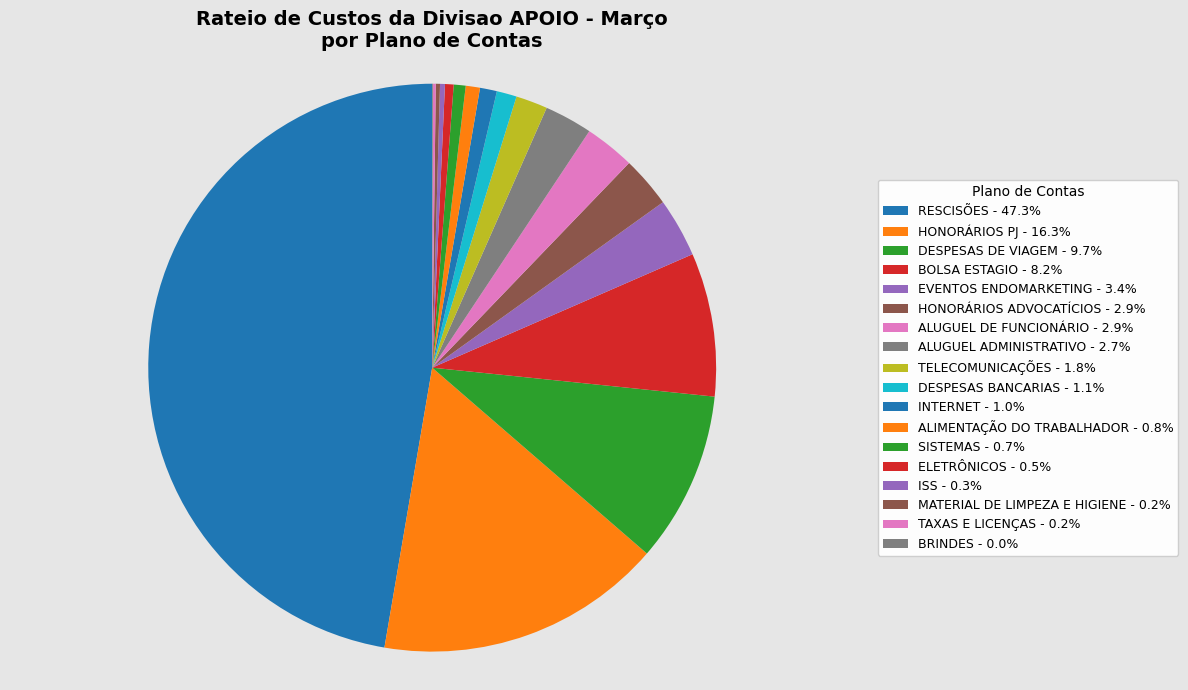

In [42]:
def plotar_pizza_rateio(
    tabela: pd.DataFrame,
    coluna_grupo: str = COLUNA_AGRUPAMENTO,
    coluna_valor: str = "valor_rateado",
    coluna_pct: str | None = "participacao_pct",
    titulo: str = "Rateio de Custos da Divisao APOIO\npor Plano de Contas",
):
    tabela_ord = tabela.sort_values(coluna_valor).reset_index(drop=True)

    valores_abs = tabela_ord[coluna_valor].abs()
    grupos = tabela_ord[coluna_grupo].astype(str)

    if coluna_pct and coluna_pct in tabela_ord.columns:
        pcts = tabela_ord[coluna_pct].astype(float)
    else:
        soma = float(valores_abs.sum())
        pcts = valores_abs / soma * 100 if soma else valores_abs * 0

    legend_labels = [f"{g} - {p:.1f}%" for g, p in zip(grupos, pcts)]

    fig, ax = plt.subplots(figsize=(12, 7), facecolor="#e6e6e6")
    ax.set_facecolor("#e6e6e6")

    wedges, _texts = ax.pie(
        valores_abs,
        labels=None,
        autopct=None,
        startangle=90,
        shadow=False,
    )

    ax.legend(
        wedges,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        framealpha=0.95,
        title="Plano de Contas",
        title_fontsize=10,
    )
    ax.set_title(titulo, fontsize=14, fontweight="bold")
    ax.axis("equal")
    plt.tight_layout()
    return fig, ax


_titulo_pizza = f"Rateio de Custos da Divisao APOIO - {NOME_MES}\npor Plano de Contas"
fig, ax = plotar_pizza_rateio(resultado, titulo=_titulo_pizza)


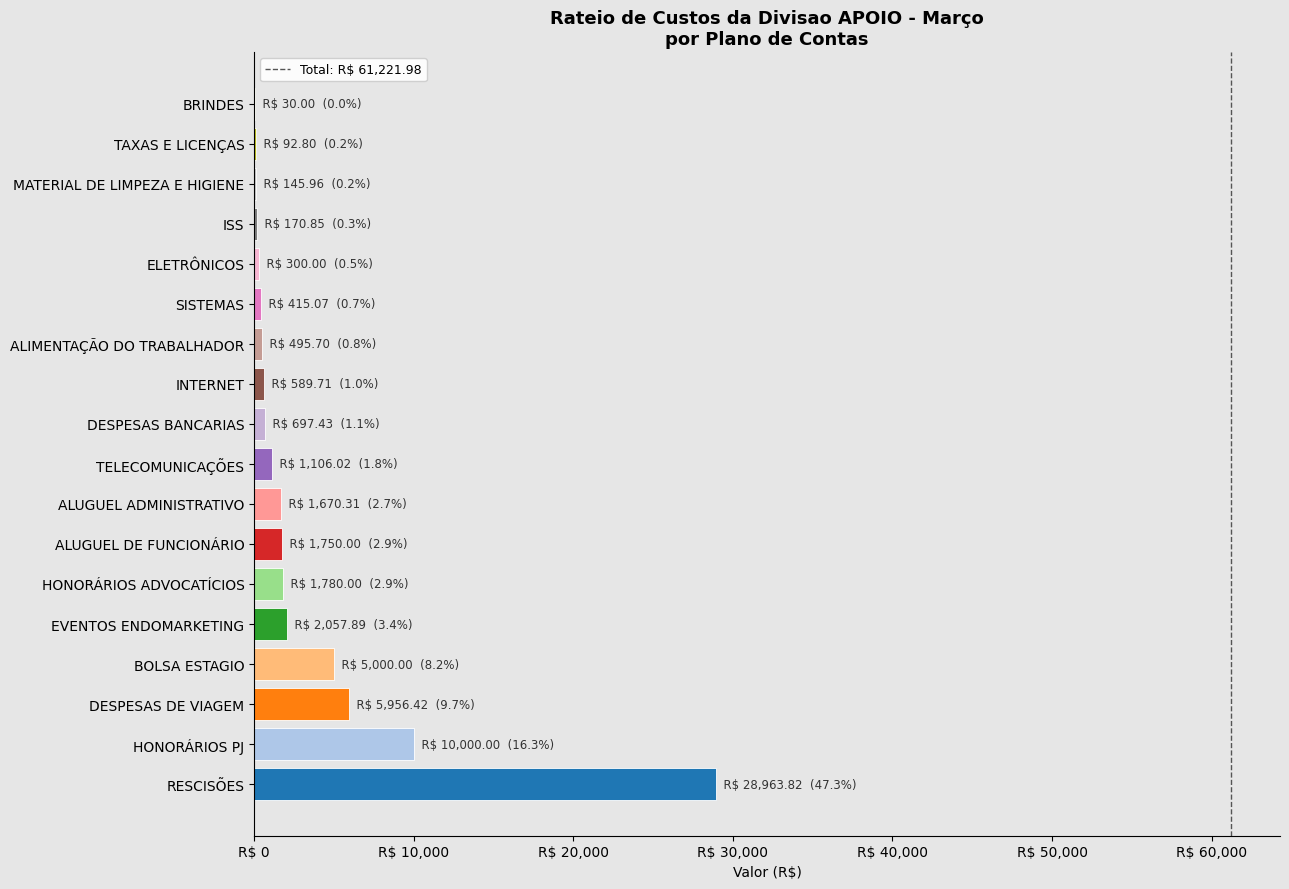

In [43]:
def plotar_barras_rateio(
    tabela: pd.DataFrame,
    coluna_grupo: str = COLUNA_AGRUPAMENTO,
    coluna_valor: str = "valor_rateado",
    coluna_pct: str | None = "participacao_pct",
    titulo: str = "Rateio de Custos da Divisao APOIO\npor Plano de Contas",
):
    # Ordena do maior custo (mais negativo) para o menor — visualmente do topo para baixo
    tabela_ord = tabela.sort_values(coluna_valor, ascending=True).reset_index(drop=True)

    valores_abs = tabela_ord[coluna_valor].abs()
    grupos = tabela_ord[coluna_grupo].astype(str)

    if coluna_pct and coluna_pct in tabela_ord.columns:
        pcts = tabela_ord[coluna_pct].astype(float)
    else:
        soma = float(valores_abs.sum())
        pcts = valores_abs / soma * 100 if soma else valores_abs * 0

    total_abs = float(valores_abs.sum())

    fig, ax = plt.subplots(figsize=(13, max(6, len(grupos) * 0.5)), facecolor="#e6e6e6")
    ax.set_facecolor("#e6e6e6")

    bars = ax.barh(
        grupos,
        valores_abs,
        color=plt.cm.tab20.colors[: len(grupos)],
        edgecolor="white",
        linewidth=0.6,
    )

    # Anota valor (R$) + % em cada barra
    for bar, pct, val in zip(bars, pcts, valores_abs):
        label = f"  R$ {val:,.2f}  ({pct:.1f}%)"
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            ha="left",
            fontsize=8.5,
            color="#333333",
        )

    # Linha do total
    ax.axvline(total_abs, color="#555555", linestyle="--", linewidth=1, label=f"Total: R$ {total_abs:,.2f}")
    ax.legend(fontsize=9, framealpha=0.9)

    ax.set_xlabel("Valor (R$)", fontsize=10)
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))

    # Remove borda direita e superior para visual mais limpo
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    plt.tight_layout()
    return fig, ax


_titulo_barras = f"Rateio de Custos da Divisao APOIO - {NOME_MES}\npor Plano de Contas"
fig2, ax2 = plotar_barras_rateio(resultado, titulo=_titulo_barras)


In [44]:
# (Opcional) Salvar resultado e graficos com nome do mes
_saida_dir = ROOT / "02-Referencias"
_saida_dir.mkdir(parents=True, exist_ok=True)
saida_excel = _saida_dir / f"rateio_apoio_{NOME_MES}.xlsx"
saida_pizza = _saida_dir / f"rateio_apoio_{NOME_MES}_pizza.png"
saida_barras = _saida_dir / f"rateio_apoio_{NOME_MES}_barras.png"

resultado.to_excel(saida_excel, index=False)
fig.savefig(saida_pizza, dpi=160, bbox_inches="tight")
fig2.savefig(saida_barras, dpi=160, bbox_inches="tight")

print(f"Tabela salva em : {saida_excel.resolve()}")
print(f"Pizza salva em  : {saida_pizza.resolve()}")
print(f"Barras salvo em : {saida_barras.resolve()}")


Tabela salva em : C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\Rateio_APOIO_Março.xlsx
Pizza salva em  : C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\rateio_apoio_Março_pizza.png
Barras salvo em : C:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\rateio_apoio_Março_barras.png
